Mini project : Fake news detection

Link to download datasets if not already done and check the readme to organize the files:
1. https://www.kaggle.com/datasets/csmalarkodi/isot-fake-news-dataset/data?select=True.csv
2. https://www.kaggle.com/datasets/jillanisofttech/fake-or-real-news

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import string
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

from joblib import Parallel, delayed
import multiprocessing

from collections import Counter
from wordcloud import WordCloud

I Importing the data and cleaning it

In [4]:
# load dataframe from CSV file
df_fake = pd.read_csv("data/Fake.csv")
df_fake['fake'] = 1 # add label for fake news
df_true = pd.read_csv("data/True.csv")
df_true['fake'] = 0 # add label for true news
df = pd.concat([df_fake, df_true], ignore_index=True)


In [5]:
# Check if there are url in date column
print("Lines with url in date column:")
url_like = df['date'].str.contains('http', na=False)
print(df[url_like]['date'])
print(df[url_like]['date'].shape[0], "entries contain 'http' in the 'date' column.")

df = df[~url_like]  # remove the 9 rows with url in the column date
print(df[url_like]['date'].shape[0], "entries contain 'http' in the 'date' column after cleaning. (should be 0)")
df.info()

Lines with url in date column:
9358     https://100percentfedup.com/served-roy-moore-v...
15507    https://100percentfedup.com/video-hillary-aske...
15508    https://100percentfedup.com/12-yr-old-black-co...
15839    https://fedup.wpengine.com/wp-content/uploads/...
15840    https://fedup.wpengine.com/wp-content/uploads/...
17432    https://fedup.wpengine.com/wp-content/uploads/...
17433    https://fedup.wpengine.com/wp-content/uploads/...
21869    https://fedup.wpengine.com/wp-content/uploads/...
21870    https://fedup.wpengine.com/wp-content/uploads/...
Name: date, dtype: object
9 entries contain 'http' in the 'date' column.
0 entries contain 'http' in the 'date' column after cleaning. (should be 0)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 44889 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44889 non-null  object
 1   text     44889 non-null  object
 2   subject  44889 non-null  obj

C:\Users\rems9\AppData\Local\Temp\ipykernel_19436\3813996360.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[url_like]['date'].shape[0], "entries contain 'http' in the 'date' column after cleaning. (should be 0)")


In [6]:
print(df.isna().sum()) # there are no NA

title      0
text       0
subject    0
date       0
fake       0
dtype: int64


In [7]:
# Check if there are URLs in the title column
print("Lines with URL in title column:")
url_in_title = df['title'].str.contains('http', na=False)
print(df[url_in_title]['title'])
print(url_in_title.sum(), "entries contain 'http' in the 'title' column.")

Lines with URL in title column:
Series([], Name: title, dtype: object)
0 entries contain 'http' in the 'title' column.


In [8]:
# Check if there are URLs in the text column
print("Lines with URL in text column:")
url_in_text = df['text'].str.contains('http', na=False)
print(df[url_in_text]['text'])
print(url_in_text.sum(), "entries contain 'http' in the 'text' column.")



position = df['text'][2].find('http')
print("Example of a part of text with an url ;" ,df['text'][2][position-50:position+100]) #

Lines with URL in text column:
2        On Friday, it was revealed that former Milwauk...
3        On Christmas day, Donald Trump announced that ...
16       A new animatronic figure in the Hall of Presid...
19       Senate Majority Whip John Cornyn (R-TX) though...
27        Judge  Jeanine Pirro has continued her scream...
                               ...                        
23426    21st Century Wire says This latest bombshell r...
23440     21st Century Wire says One TV personality Tru...
23463    Patrick Henningsen 21st Century Wire UPDATE: 1...
23465    21st Century Wire says Various parties in Wash...
23479    21st Century Wire says Al Jazeera America will...
Name: text, Length: 3291, dtype: object
3291 entries contain 'http' in the 'text' column.
Example of a part of text with an url ;  not to charge Clarke, email search warrant filed https://t.co/zcbyc4Wp5b  KeithLeBlanc (@KeithLeBlanc63) December 30, 2017I just hope the rest of the


In [9]:


# Function that replaces URLs with a special token <URL>
def replace_urls(text):
    url_pattern = re.compile(
        r'(http\S+|www\.\S+|\b(?:[a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}(?:/\S*)?)'
    )
    return url_pattern.sub('<URL>', str(text))

# replace urls
df['text'] = df['text'].apply(replace_urls)
url_in_text = df['text'].str.contains('http', na=False)
print(url_in_text.sum(), "entries contain 'http' in the 'text' column. (should be 0)")

0 entries contain 'http' in the 'text' column. (should be 0)


In [10]:
# Extract Twitter handles from the text column
twitter_handles = df['text'].str.extractall(r'@(\w+)')[0]
# Count the occurrences of each handle
handle_counts = twitter_handles.value_counts()
# Print the top 10 most common Twitter handles
print(handle_counts.head(10))

realDonaldTrump    4525
POTUS               380
FoxNews             295
HillaryClinton      239
seanhannity         230
CNN                 214
foxandfriends       147
nytimes             138
SarahPalinUSA       126
IvankaTrump         110
Name: 0, dtype: int64


In [11]:
# Function to remove Twitter handles
def remove_twitter_handles(text):
    return re.sub(r'@\w+', '', text)

df['text'] = df['text'].apply(remove_twitter_handles)

In [12]:
df['text'] = df['text'].str.lower() # lower case

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 44889 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44889 non-null  object
 1   text     44889 non-null  object
 2   subject  44889 non-null  object
 3   date     44889 non-null  object
 4   fake     44889 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 3.1+ MB


In [14]:
# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors ='coerce')
print(df['date'].isna().sum(), "entries contain invalid date format.") # check for invalid date formats
df = df.dropna(subset=['date']) # we drop the single row with invalid date format

# Find the earliest and latest dates
earliest_date = df['date'].min()
latest_date = df['date'].max()

print(f"Earliest date: {earliest_date}")
print(f"Latest date: {latest_date}")

print(df['date'].isna().sum(), "entries contain invalid date format. (should be 0)")

1 entries contain invalid date format.
Earliest date: 2015-03-31 00:00:00
Latest date: 2018-02-19 00:00:00
0 entries contain invalid date format. (should be 0)


In [15]:
# In this cell we create an other version of the dataframe where we removed stop words for data analysis

# Download stopwords
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
# Function to remove stop words
def remove_stop_words(text):
    """
    Function to remove stop words from a given text
    """
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)




def fast_remove_stop_words(dataframe):
    """
    Remove stop words from the 'text' colum  of a dataframe using parallel processing.
    """
    n_jobs = multiprocessing.cpu_count()
    print(f"Number of CPU cores: {n_jobs}")

    # Apply in parallel
    processed_texts = Parallel(n_jobs=n_jobs)(
        delayed(remove_stop_words)(text) for text in dataframe['text']
    )

    dataframe_stop = dataframe.copy()
    dataframe_stop['text'] = processed_texts
    return dataframe_stop


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rems9\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rems9\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


II DATA ANALYSIS

In [34]:
def data_analysis(df_processed, dataset_name):
    """
    arg : df_processed : dataframe to analyze
    arg : dataset_name : name of the dataset (for plotting)
    Function to produce plots and data analysis of the given dataframe
    """
    print("This function will produce plots and data analysis of the given dataset")
    print("Starting with statistics")
    # Create an other dataframe with stop words removed to make word clouds
    # Combine all texts into a single string
    all_text_include_stop = ' '.join(df_processed['text'])
    all_text_include_stop_no_punctuation = all_text_include_stop.translate(str.maketrans('', '', string.punctuation))
    # statitics
    print(f"Top 25 most common words (stop words included):")
    word_counts = Counter(all_text_include_stop_no_punctuation.split())
    for word, count in word_counts.most_common(25):
        print(f"  {word}: {count}")


    print("Preparing the dataframe for further analysis")
    df_stop = fast_remove_stop_words(df_processed)
    all_text = ' '.join(df_stop['text'])
    all_text_no_punctuation = all_text.translate(str.maketrans('', '', string.punctuation))

    print(f"Top 25 most common words (stop words removed):")

    word_counts = Counter(all_text_no_punctuation.split())
    for word, count in word_counts.most_common(25):
        print(f"  {word}: {count}")

    unique_word_count = len(set(all_text_include_stop_no_punctuation.split())) # count the number of unique words in the dataset
    print(f"Number of rows: {len(df_processed)}")
    print(f"Number of unique words in the dataset: {unique_word_count}")
    print(f"Average text length: {df_processed['text'].str.len().mean():.2f}")
    print(f"Median text length: {df_processed['text'].str.len().median():.2f}")




    # Count the number of '<URL>' tokens in fake news
    fake_url_count = df_processed[df_processed['fake'] == 1]['text'].str.count('<url>').sum()
    # Count the total number of tokens in fake news
    total_fake_tokens = df_processed[df_processed['fake'] == 1]['text'].str.split().apply(len).sum()
    # Compute the proportion of '<URL>' tokens in fake news
    fake_url_proportion = fake_url_count / total_fake_tokens
    print(f"Number of '<url>' tokens in fake news: {fake_url_count} and proportion of '<url>' tokens in fake news: {fake_url_proportion}")

    true_url_count = df_processed[df_processed['fake'] == 0]['text'].str.count('<url>').sum()
    # Count the total number of tokens in true news
    total_true_tokens = df_processed[df_processed['fake'] == 0]['text'].str.split().apply(len).sum()
    # Compute the proportion of '<URL>' tokens in true news
    true_url_proportion = true_url_count / total_true_tokens
    print(f"Number of '<url>' tokens in true news: {true_url_count} and proportion of '<url>' tokens in true news: {true_url_proportion}")



    print("Starting the plots")
    # Plot the statistics of category
    plt.figure(figsize=(15, 7))

    # first subplot: number of fake and true news
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, y="fake")
    plt.title("Number of fake and true news")

    # second subplot
    if 'subject' in df.columns: # plot stats of subject if it exists
        plt.subplot(1, 2, 2)
        sns.countplot(data=df, y="subject", hue ="fake")
        plt.title("Number of fake and true news by subject")
        plt.tight_layout()


    print("Starting first word cloud generation...")

    # Generate a word cloud

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

    # Plot the first word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud of {dataset_name} dataset")
    plt.show()

    # Generate word cloud for fake news
    print("Starting second word cloud generation...")
    fake_text = ' '.join(df_stop[df_stop['fake'] == 1]['text']) # filter for fake news
    fake_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_text)

    # Plot the fake news word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(fake_wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Fake News in {dataset_name} dataset")
    plt.show()

    # Generate word cloud for true news
    print("Starting third word cloud generation...")
    true_text = ' '.join(df_stop[df_stop['fake'] == 0]['text'])
    true_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(true_text)

    # Plot the true news word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(true_wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for True News in {dataset_name} dataset")
    plt.show()

    return


This function will produce plots and data analysis of the given dataframe
Starting with statistics
Top 5 most common words (stop words included):
  the: 1004864
  to: 534258
  of: 440581
  a: 407016
  and: 405615
  in: 344309
  that: 236181
  on: 189304
  s: 174376
  for: 171413
  is: 165858
  said: 130028
  he: 129911
  url: 126676
  it: 123093
  with: 117160
  was: 115580
  trump: 115496
  as: 102660
  his: 95919
  by: 94903
  has: 88373
  be: 82737
  have: 82322
  not: 80751
Preparing the dataframe for further analysis
Number of CPU cores: 6
Top 5 most common words (stop words removed):
  url: 130656
  said: 130196
  trump: 128611
  ’: 70768
  us: 63310
  would: 54989
  “: 54140
  ”: 53861
  president: 52245
  people: 41271
  one: 35722
  state: 32303
  also: 31199
  new: 30987
  reuters: 28796
  donald: 27695
  clinton: 27562
  house: 27153
  obama: 27142
  government: 26928
  states: 26159
  republican: 24357
  could: 23942
  united: 23531
  told: 23348
Number of rows: 44888
Numbe

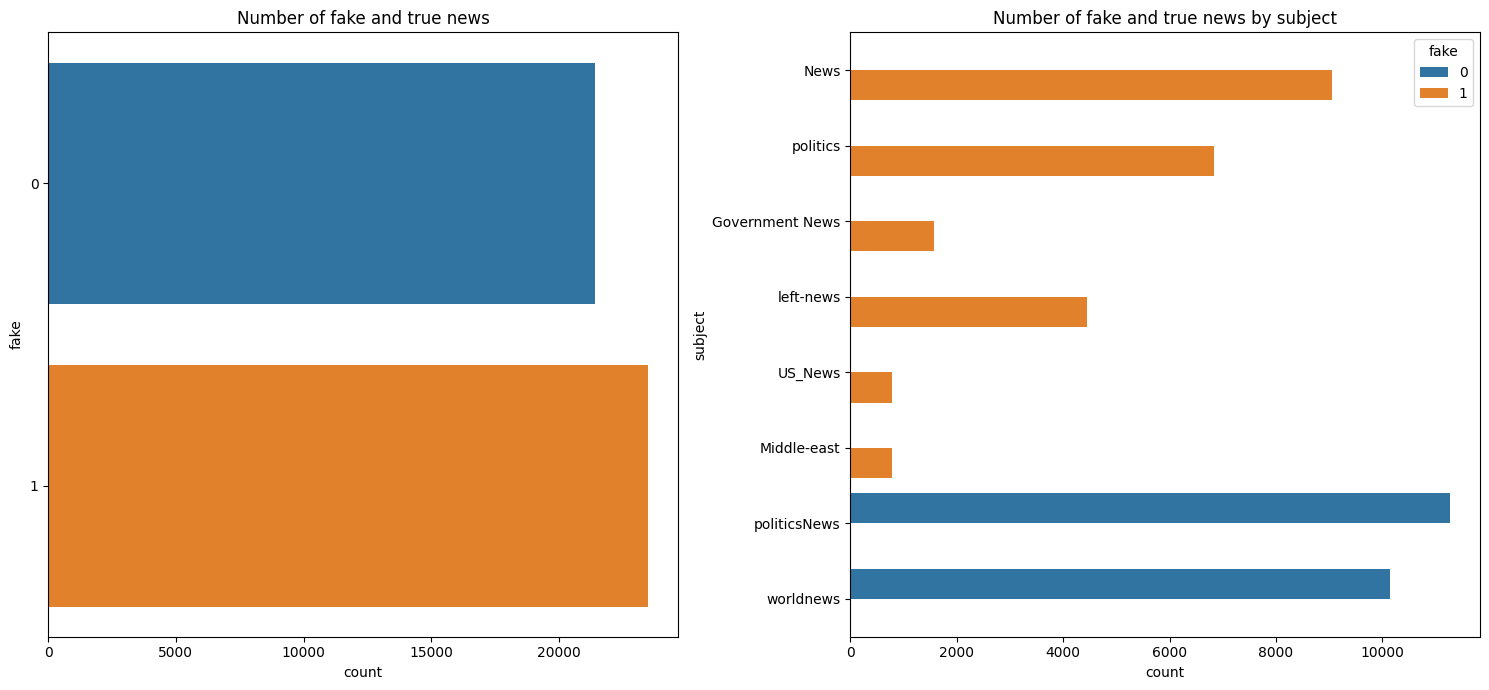

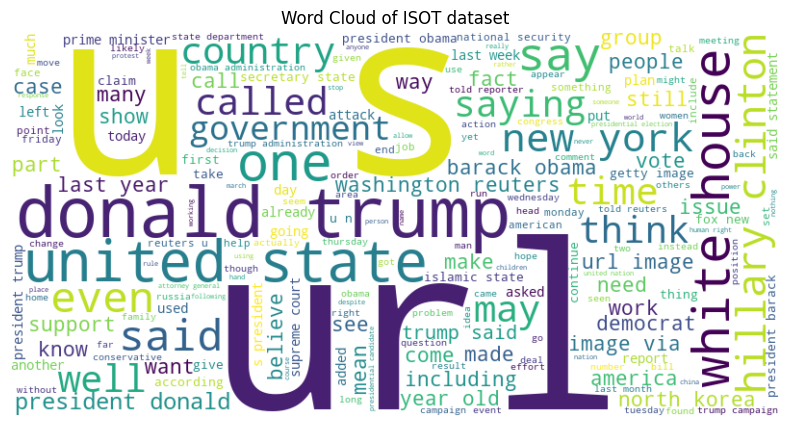

Starting second word cloud generation...


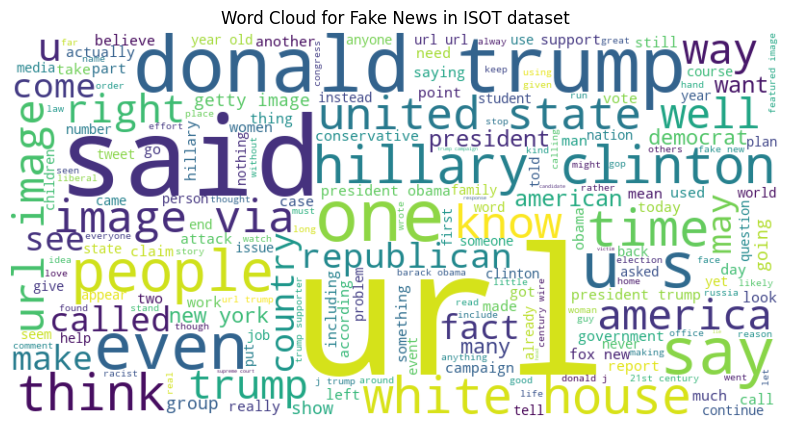

Starting third word cloud generation...


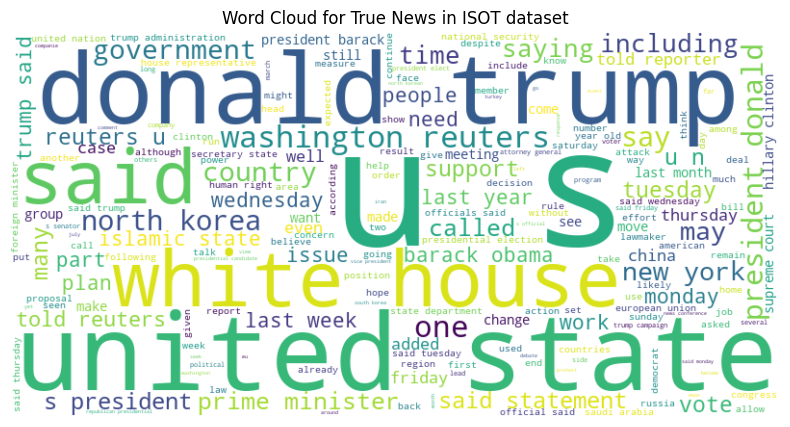

In [33]:
data_analysis(df, "ISOT") # can take a few minutes to run

MODELISATION

In [ ]:
# shuffle and split in 80% train, 10% dev and 10% test sets.
# Here we only the use the text and not the other columns for features.
# Here I use the version of the dataset that still have stop words because I will use BERT
X_train, X_inter, y_train, y_inter = train_test_split(df['text'], df['fake'], test_size=0.2, random_state=42)
X_test,X_dev, y_test, y_dev = train_test_split(X_inter, y_inter, test_size=0.5, random_state=42)

In [ ]:
def get_bert_embeddings(df_texts):
    """
    Function to get BERT embeddings for a list of texts.
    Input : df_texts: list of texts
    Output : cls_embed_list: list of BERT CLS embeddings for the texts

    """
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True) # I use autoTokenizer because sliding window is not working with BertTokenizer
    model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True)
    model.eval()
    cls_embed_list = []
    key_filter = ['input_ids', 'attention_mask']


    i=0
    #for text in df_texts:
    for text in tqdm(df_texts, desc="Extracting BERT embeddings"):

        #print(i)
        #print(text)
        #i+=1
        inputs = tokenizer(text,return_tensors='pt', max_length=512, truncation=True, padding='max_length', stride=128, return_overflowing_tokens=True) # sliding window because the text is too long for BERT
        model_inputs = {k: v for k, v in inputs.items() if k in key_filter} # filter to match bert model inputs
        with torch.no_grad():
            outputs = model(**model_inputs)
            cls_embed = outputs.last_hidden_state[:, 0, :] # get embedding of the [CLS] token
            cls_embed_mean = cls_embed.mean(dim=0) # average the cls of all chunks
            cls_embed_list.append(cls_embed_mean) # add to list

    return cls_embed_list


In [ ]:
np.random.seed(42)
indices = np.random.choice(len(X_train), size=50, replace=False) # randomly select indices
X_train_small = [X_train.iloc[i] for i in indices] # I use only a small random portion of the training data set to train faster as I have very limited computing power
y_train_small = [y_train.iloc[i] for i in indices]

In [ ]:
cls_embed_list_train = get_bert_embeddings(X_train_small)
X_train_small_features = np.vstack(cls_embed_list_train)
print(X_train_small_features.shape)

In [ ]:
# function to train different small classifiers
def train_classifiers(X_features, y_labels):
    """
    Function to train different small classifiers
    """
    classifiers = {}

    # dummy classifier
    dummy_clf = DummyClassifier(strategy="most_frequent")
    dummy_clf.fit(X_train_small_features, y_train_small)
    classifiers['Dummy'] = dummy_clf

    # logistic regression
    clf1 = LogisticRegression(max_iter=1000)
    clf1.fit(X_train_small_features, y_train_small)
    classifiers['Logistic Regression'] = clf1

    # random forest
    clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
    clf2.fit(X_features, y_labels)
    classifiers['RandomForest'] = clf2

    # SVM
    clf3 = SVC(probability=True, kernel='linear')
    clf3.fit(X_features, y_labels)
    classifiers['SVM'] = clf3

    # Gradient Boosting
    clf4 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
    clf4.fit(X_features, y_labels)
    classifiers['GradientBoosting'] = clf4

    return classifiers


In [ ]:
classifiers = train_classifiers(X_train_small_features, y_train_small)

Evaluation of the trained model

In [ ]:
indices_test = np.random.choice(len(X_test), size=50, replace=False) # randomly select indices
X_test_small = [X_test.iloc[i] for i in indices_test] # I use only a small random portion of the training data set to train faster as I have very limited computing power
y_test_small = [y_test.iloc[i] for i in indices_test]
cls_embed_list_test = get_bert_embeddings(X_test_small)
X_test_small_features = np.vstack(cls_embed_list_test)

In [ ]:
def test_classifiers(classifiers, X_test_features, y_test_labels):
    """
    Function to test different classifiers
    """
    results = {}
    for name, clf in classifiers.items():
        y_pred = clf.predict(X_test_features)
        print(f"Results for the classifier: {name}: ")
        print(classification_report(y_test_labels, y_pred))
    return

In [ ]:
test_classifiers(classifiers, X_test_small_features, y_test_small)


Analysing impact of words/tokens on classification

Testing the generalizability on an other dataset

Preprocessing the 'Fake or Real News' dataset

In [33]:
new_df = pd.read_csv("data/fake_or_real_news.csv")
new_df["label"]= new_df["label"].map({"FAKE": 1, "REAL": 0}) # map labels to 1 and 0
new_df = new_df.rename(columns= {"label": "fake"})
new_df = new_df.drop("Unnamed: 0", axis=1 )

# URLs
url_in_text = new_df['text'].str.contains('http', na=False)
print(url_in_text.sum(), "entries contain 'http' in the 'text' column.")
# replace urls in the text by a special token <URL>
new_df['text'] = new_df['text'].apply(replace_urls)
url_in_text = new_df['text'].str.contains('http', na=False)
print(url_in_text.sum(), "entries now contain 'http' in the 'text' column. (should be 0)")

# removing twitter handles
new_df['text'] = new_df['text'].apply(remove_twitter_handles)
new_df['text'] = new_df['text'].str.lower() # lower case
new_df.info()

295 entries contain 'http' in the 'text' column.
0 entries now contain 'http' in the 'text' column. (should be 0)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   6335 non-null   object
 1   text    6335 non-null   object
 2   fake    6335 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 148.6+ KB


Analysing the new dataset 'Fake or Real News'

This function will produce plots and data analysis of the given dataframe
Starting with statistics
Number of '<url>' tokens in fake news: 2711 and proportion of '<url>' tokens in fake news: 0.0012618463917290646
Number of '<url>' tokens in true news: 398 and proportion of '<url>' tokens in true news: 0.00014373311000530513
Starting the plots
Number of CPU cores: 6
Starting first word cloud generation...


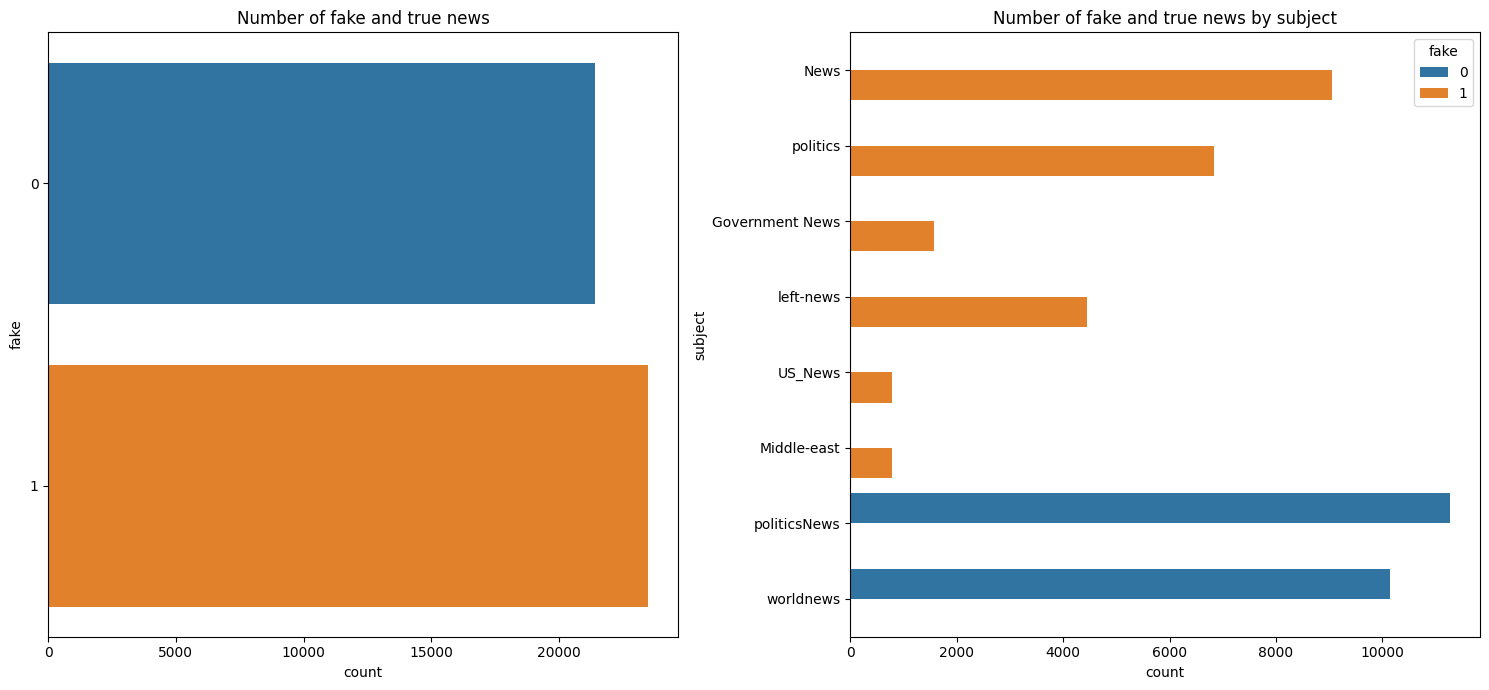

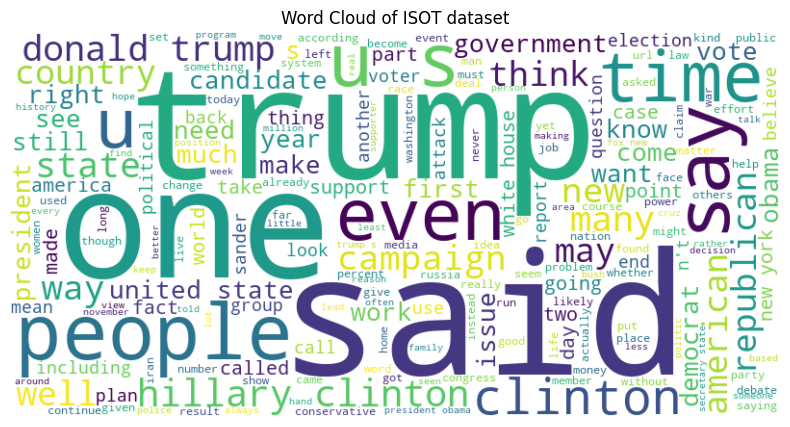

Starting second word cloud generation...


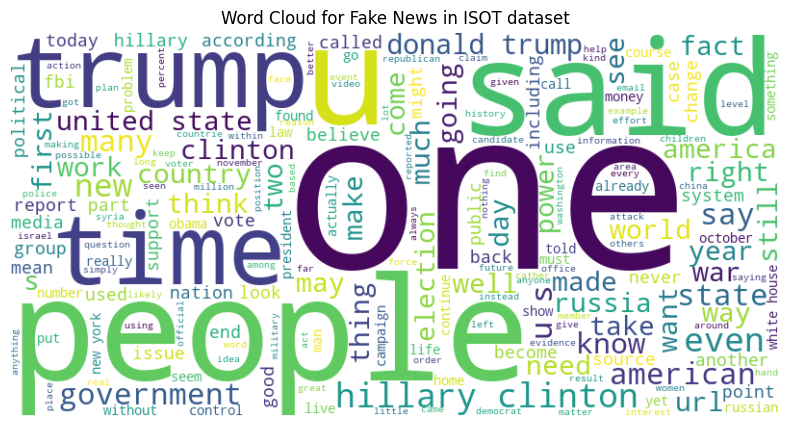

Starting third word cloud generation...


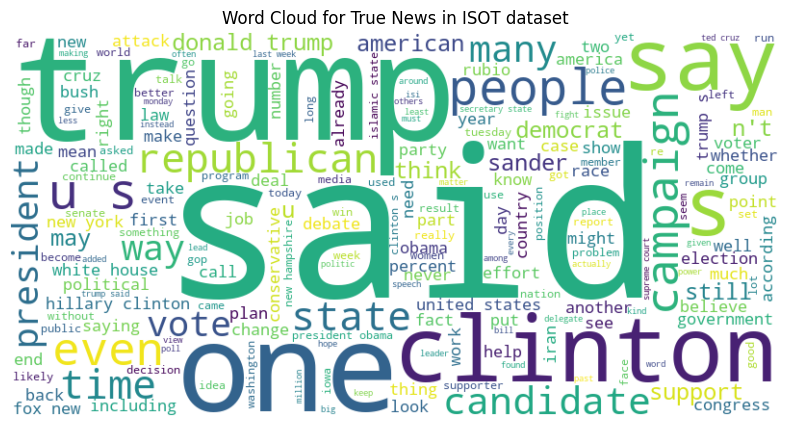

In [ ]:
data_analysis(new_df, "'Fake or Real News'") # can take a few minutes to run

Testing the model trained on the ISOT dataset on the 'Fake or Real News' dataset.

In [ ]:
X_new = new_df['text']
y_new = new_df['fake']
indices_new = np.random.choice(len(X_new), size=50, replace=False) # randomly select indices
X_new_small = [X_new.iloc[i] for i in indices_new]
y_new_small = [y_new.iloc[i] for i in indices_new]

cls_embed_list_new = get_bert_embeddings(X_new_small)
X_new_small_features = np.vstack(cls_embed_list_new)


In [ ]:
test_classifiers(classifiers, X_new_small_features, y_new_small)